In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys, os

print(sys.executable)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Allocated: {round(torch.cuda.memory_allocated(0)/1024**3,1)} GB")


/home/hoffmanp/diff_env/.venv/bin/python
device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB


In [4]:

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("Seed set to:", seed)

SEED = 2026
set_seed(SEED)


Seed set to: 2026


In [6]:
# -----------------------------
# Data: MNIST -> [-1, 1], then precondition x' = Mx, then normalize in x' space
# -----------------------------

IMG_SIZE = 28
BATCH_SIZE = 128
D = IMG_SIZE * IMG_SIZE

# ---------- Preconditioner M (784x784) ----------
# Note that the preconditioner M is DxD for D=784

M = torch.load("M_784.pt", map_location="cpu")     # load
M = M.to(device=device, dtype=torch.float32)       # move to GPU
if M.shape == (784, 784):
    print("Our imported M has the correct dimension: 784x784")

try:
    M_inv = torch.linalg.inv(M)
except RuntimeError:
    M_inv = torch.linalg.pinv(M)

# We'll use CPU copies inside dataset transforms (transforms run in dataloader workers on CPU)
M_cpu = M.detach().cpu()
# For sampling inversion we keep device copies (already on device)

# ---------- Pass 1: compute mean/std AFTER applying M ----------
@torch.no_grad()
def compute_precond_stats_mnist(root="./data", batch_size=512, device=device, eps=1e-8):
    # Raw-to-[-1,1] transform only (no M, no normalization yet)
    base_tf = transforms.Compose([
        transforms.ToTensor(),                          # MNIST data in [0,1] 
        transforms.Lambda(lambda x: x * 2.0 - 1.0),      #  [-1,1]
    ])
    ds = datasets.MNIST(root=root, train=True, download=True, transform=base_tf)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )

    # Compute GLOBAL scalar mean/std over all pixels in preconditioned space.
    # (This keeps noise roughly isotropic; per-dimension normalization can distort geometry.)
    n = 0
    s1 = torch.tensor(0.0, device=device)
    s2 = torch.tensor(0.0, device=device)

    for x, _ in loader:
        x = x.to(device, non_blocking=(device.type == "cuda"))     # [B,1,28,28] in [-1,1]
        x_flat = x.view(x.size(0), -1)                             # [B,784]
        x_pre = x_flat @ M.T                                       # [B,784]  (equiv to M @ vec)
        s1 += x_pre.sum()
        s2 += (x_pre * x_pre).sum()
        n += x_pre.numel()

    mean = s1 / n
    var = s2 / n - mean * mean
    std = torch.sqrt(torch.clamp(var, min=eps))
    return mean.detach(), std.detach()

pre_mean, pre_std = compute_precond_stats_mnist(root="./data", batch_size=512, device=device)
# Move stats to CPU for transform usage (and keep device copies for undo if you like)
pre_mean_cpu = pre_mean.cpu()
pre_std_cpu = pre_std.cpu()

# Target scale in preconditioned+normalized space.
# - target_std=1.0: very common, aligns with N(0,1) noise conventions
# - target_std=0.5: keeps typical magnitudes closer to [-1,1]-ish without hard clipping
TARGET_STD = 1.0
EPS = 1e-6

class PrecondNormalizeMNIST:
    """
    PIL -> tensor in preconditioned+normalized space.

    Pipeline:
      PIL -> ToTensor in [0,1]
          -> scale to [-1,1]
          -> flatten (784)
          -> apply M (784x784)
          -> global normalize using stats computed in precond space
          -> scale by TARGET_STD
          -> reshape back to [1,28,28]
    """
    def __init__(self, M_cpu, mean_cpu, std_cpu, target_std=1.0, eps=1e-6):
        self.to_tensor = transforms.ToTensor()
        self.M = M_cpu.to(dtype=torch.float32)
        self.mean = mean_cpu.to(dtype=torch.float32)
        self.std = std_cpu.to(dtype=torch.float32)
        self.target_std = float(target_std)
        self.eps = float(eps)

    def __call__(self, img):
        x = self.to_tensor(img)              # [1,28,28] in [0,1]
        x = x * 2.0 - 1.0                    # [-1,1]
        x_flat = x.view(-1)                  # [784]
        x_pre = self.M @ x_flat              # [784]
        x_norm = (x_pre - self.mean) / (self.std + self.eps)
        x_norm = x_norm * self.target_std
        return x_norm.view(1, IMG_SIZE, IMG_SIZE)

transform = PrecondNormalizeMNIST(
    M_cpu=M_cpu,
    mean_cpu=pre_mean_cpu,
    std_cpu=pre_std_cpu,
    target_std=TARGET_STD,
    eps=EPS,
)

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=True
)

# ---------- Updated apply/undo for when you need them ----------
def apply_precond(x: torch.Tensor) -> torch.Tensor:
    """
    If you ever have x in ORIGINAL space [-1,1], this maps it into the
    SAME space the model trains/samples in (preconditioned + normalized).

    x: [B,1,28,28] in [-1,1] -> [B,1,28,28] normalized precond space
    """
    x_flat = x.view(x.size(0), -1)                 # [B,784]
    x_pre = x_flat @ M.T                           # [B,784]
    x_norm = (x_pre - pre_mean) / (pre_std + EPS)  # stats on device
    x_norm = x_norm * TARGET_STD
    return x_norm.view(x.size(0), 1, IMG_SIZE, IMG_SIZE)

def undo_precond(x: torch.Tensor) -> torch.Tensor:
    """
    Invert normalization + M to go back to ORIGINAL space [-1,1].

    x: [B,1,28,28] normalized precond space -> [B,1,28,28] in [-1,1]
    """
    x_flat = x.view(x.size(0), -1)                      # [B,784]
    x_pre = x_flat / TARGET_STD                         # undo target scaling
    x_pre = x_pre * (pre_std + EPS) + pre_mean          # undo normalization
    x_raw = x_pre @ M_inv.T                             # undo M
    return x_raw.view(x.size(0), 1, IMG_SIZE, IMG_SIZE)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [ ]:
# -----------------------------
# Diffusion schedule
# -----------------------------

T = 400
beta_start, beta_end = 1e-4, 0.02

betas = torch.linspace(beta_start, beta_end, T, device=device)              # [T]
alphas = 1.0 - betas                                                       # [T]
alpha_bar = torch.cumprod(alphas, dim=0)                                   # [T]
alpha_bar_prev = torch.cat([torch.ones(1, device=device), alpha_bar[:-1]]) # [T]

sqrt_alpha_bar = torch.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
posterior_variance = torch.clamp(posterior_variance, min=1e-20)

def extract(a_1d: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    # a_1d: [T], t: [B] long -> [B,1,1,1]
    return a_1d.gather(0, t).view(-1, 1, 1, 1)

def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
    # x_t = sqrt(alpha_bar_t)*x0 + sqrt(1-alpha_bar_t)*eps
    return extract(sqrt_alpha_bar, t) * x0 + extract(sqrt_one_minus_alpha_bar, t) * noise


In [ ]:
# -----------------------------
# UNet (simple, 28x28) with time embedding
# -----------------------------

def timestep_embedding(timesteps: torch.Tensor, dim: int, max_period: int = 10000) -> torch.Tensor:
    """Sinusoidal timestep embeddings. timesteps: [B] -> [B, dim]."""
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=timesteps.device) / half
    )
    args = timesteps.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

def _gn_groups(ch: int) -> int:
    for g in (32, 16, 8, 4, 2, 1):
        if ch % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, temb_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(_gn_groups(in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.temb_proj = nn.Linear(temb_dim, out_ch)

        self.norm2 = nn.GroupNorm(_gn_groups(out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x: torch.Tensor, temb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.temb_proj(F.silu(temb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class UNet28(nn.Module):
    """
    Simple 28x28 UNet:
      Down: 28 -> 14 -> 7 -> 4
      Up:   4  -> 7  -> 14 -> 28
    """
    def __init__(self, in_ch: int = 1, base: int = 64, temb_dim: int = 256):
        super().__init__()
        self.temb_dim = temb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(temb_dim, temb_dim),
            nn.SiLU(),
            nn.Linear(temb_dim, temb_dim),
        )

        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)

        # 28x28 -> 14x14
        self.d1a = ResBlock(base, base, temb_dim)
        self.d1b = ResBlock(base, base, temb_dim)
        self.down1 = nn.Conv2d(base, base * 2, 4, stride=2, padding=1)

        # 14x14 -> 7x7
        self.d2a = ResBlock(base * 2, base * 2, temb_dim)
        self.d2b = ResBlock(base * 2, base * 2, temb_dim)
        self.down2 = nn.Conv2d(base * 2, base * 4, 4, stride=2, padding=1)

        # 7x7 -> 4x4
        self.d3a = ResBlock(base * 4, base * 4, temb_dim)
        self.d3b = ResBlock(base * 4, base * 4, temb_dim)
        self.down3 = nn.Conv2d(base * 4, base * 8, 3, stride=2, padding=1)

        # middle 4x4
        self.m1 = ResBlock(base * 8, base * 8, temb_dim)
        self.m2 = ResBlock(base * 8, base * 8, temb_dim)

        # up: 4 -> 7
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 3, stride=2, padding=1)  # 4 -> 7
        self.u3a = ResBlock(base * 8, base * 4, temb_dim)  # concat skip7
        self.u3b = ResBlock(base * 4, base * 4, temb_dim)

        # up: 7 -> 14
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 4, stride=2, padding=1)  # 7 -> 14
        self.u2a = ResBlock(base * 4, base * 2, temb_dim)  # concat skip14
        self.u2b = ResBlock(base * 2, base * 2, temb_dim)

        # up: 14 -> 28
        self.up1 = nn.ConvTranspose2d(base * 2, base, 4, stride=2, padding=1)      # 14 -> 28
        self.u1a = ResBlock(base * 2, base, temb_dim)  # concat skip28
        self.u1b = ResBlock(base, base, temb_dim)

        self.out_norm = nn.GroupNorm(_gn_groups(base), base)
        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        temb = timestep_embedding(t, self.temb_dim)
        temb = self.time_mlp(temb)

        h = self.in_conv(x)

        # 28
        h = self.d1a(h, temb)
        h = self.d1b(h, temb)
        skip28 = h
        h = self.down1(h)  # 14

        # 14
        h = self.d2a(h, temb)
        h = self.d2b(h, temb)
        skip14 = h
        h = self.down2(h)  # 7

        # 7
        h = self.d3a(h, temb)
        h = self.d3b(h, temb)
        skip7 = h
        h = self.down3(h)  # 4

        # middle
        h = self.m1(h, temb)
        h = self.m2(h, temb)

        # up 4->7
        h = self.up3(h)
        h = torch.cat([h, skip7], dim=1)
        h = self.u3a(h, temb)
        h = self.u3b(h, temb)

        # up 7->14
        h = self.up2(h)
        h = torch.cat([h, skip14], dim=1)
        h = self.u2a(h, temb)
        h = self.u2b(h, temb)

        # up 14->28
        h = self.up1(h)
        h = torch.cat([h, skip28], dim=1)
        h = self.u1a(h, temb)
        h = self.u1b(h, temb)

        return self.out_conv(F.silu(self.out_norm(h)))

In [ ]:
# -----------------------------
# DDPM training on preconditioned MNIST
# -----------------------------

ddpm = UNet28(in_ch=1, base=64, temb_dim=256).to(device)
ddpm_opt = torch.optim.AdamW(ddpm.parameters(), lr=2e-4)

DDPM_EPOCHS = 2

ddpm.train()
for epoch in range(1, DDPM_EPOCHS + 1):
    pbar = tqdm(train_loader, desc=f"[DDPM] Epoch {epoch}/{DDPM_EPOCHS}", leave=True)
    ema = None
    for x0, _ in pbar:
        # x0 is ALREADY in normalized preconditioned space 

        x0 = x0.to(device, non_blocking=(device.type == "cuda"))

        t = torch.randint(0, T, (x0.size(0),), device=device, dtype=torch.long)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)

        pred_noise = ddpm(xt, t)
        loss = F.mse_loss(pred_noise, noise)

        ddpm_opt.zero_grad(set_to_none=True)
        loss.backward()
        ddpm_opt.step()

        ema = loss.item() if ema is None else (0.95 * ema + 0.05 * loss.item())
        pbar.set_postfix(loss=f"{ema:.4f}")
    print(f"[DDPM] Epoch {epoch}: loss={ema:.4f}")

[DDPM] Epoch 1/2: 100%|██████████| 468/468 [00:33<00:00, 13.83it/s, loss=0.0629]


[DDPM] Epoch 1: loss=0.0629


[DDPM] Epoch 2/2: 100%|██████████| 468/468 [00:38<00:00, 12.22it/s, loss=0.0556]

[DDPM] Epoch 2: loss=0.0556


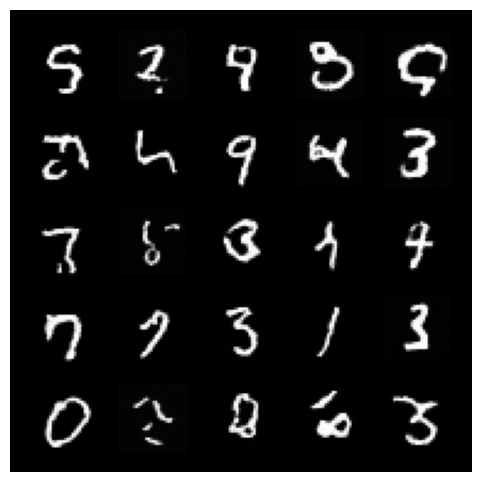

In [ ]:
# -----------------------------
# DDPM sampling
# -----------------------------

@torch.no_grad()
def p_sample_loop(model: nn.Module, n_samples: int = 25) -> torch.Tensor:
    model.eval()
    x = torch.randn(n_samples, 1, IMG_SIZE, IMG_SIZE, device=device)

    for i in tqdm(reversed(range(T)), total=T, desc="[DDPM] Sampling", leave=False):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta_t = extract(betas, t)
        sqrt_1m_ab_t = extract(sqrt_one_minus_alpha_bar, t)
        sqrt_recip_a_t = extract(sqrt_recip_alphas, t)

        # mu_theta(x_t, t)
        model_mean = sqrt_recip_a_t * (x - beta_t * eps / sqrt_1m_ab_t)

        if i == 0:
            x = model_mean
        else:
            var = extract(posterior_variance, t)
            x = model_mean + torch.sqrt(var) * torch.randn_like(x)

    return x


ddpm_samples_pre = p_sample_loop(ddpm, n_samples=25)

# Now invert normalization + M to go back to original [-1,1] image space!
ddpm_samples_raw = undo_precond(ddpm_samples_pre).clamp(-1, 1)

torch.save(ddpm_samples_raw.cpu(), "ddpm_samples_raw.pt")


# Make sure to scale from [-1,1] --> [0,1] for visualization
ddpm_samples_vis = (ddpm_samples_raw + 1) / 2 # 
grid = make_grid(ddpm_samples_vis, nrow=5, padding=8)
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu(), cmap="gray")
plt.show()


2.9.1+cu128
device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB
Seed set to: 2026


[DDPM:identity] Epoch 1/2: 100%|██████████| 468/468 [00:19<00:00, 24.35it/s, loss=0.0629]


[DDPM:identity] Epoch 1: loss=0.0629


[DDPM:identity] Epoch 2/2: 100%|██████████| 468/468 [00:17<00:00, 26.88it/s, loss=0.0556]


[DDPM:identity] Epoch 2: loss=0.0556
Saved DDPM checkpoint to ddpm_identity.pt


[DDPM:special] Epoch 1/2: 100%|██████████| 468/468 [00:17<00:00, 26.91it/s, loss=0.0618]


[DDPM:special] Epoch 1: loss=0.0618


[DDPM:special] Epoch 2/2: 100%|██████████| 468/468 [00:17<00:00, 27.05it/s, loss=0.0541]


[DDPM:special] Epoch 2: loss=0.0541
Saved DDPM checkpoint to ddpm_special.pt


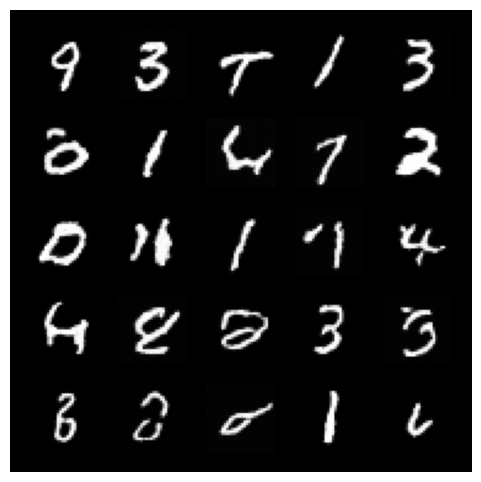

In [2]:

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
ddpm_identity = train_ddpm(
    precond_kind="identity",
    checkpoint_path="ddpm_identity.pt",
)

ddpm_special = train_ddpm(
    precond_kind="special",
    m_path="M_784.pt",
    checkpoint_path="ddpm_special.pt",
)

x_samples_raw = show_ddpm_samples(ddpm_special, n_samples=25, nrow=5)
torch.save(x_samples_raw.cpu(), "ddpm_samples_raw.pt")